<a href="https://colab.research.google.com/github/SameerPasha565/Air-pollution-analysis/blob/main/Prac1Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Air Quality Analysis of Beijing(2013-2017)**

**Overview**

Air pollution is a critical environmental challenge, with particulate matter (PM 2.5) posing significant risk to cardiovascular and respiratory health. This project analyses hourly air quality and meteorological data from four monitoring stations in Beijing, China, covering the period from **1 March 2013 to 28 February 2017**.

**Objectives**

The 4 selected stations are:
- **Urban:** Dongsi, Gucheng
- **Suburban:** Changping, Huairou

This selection follows **Xu & Zhang (2020)**, who classified these stations
based on population density and geographic location within Beijing.

Following the findings of Xu & Zhang(2020), this analysis aim to:
1. Investigate the **Spatial Variability** between urban (**Dongsi, Gucheng**) and suburban (**Changping, Huairou**) stations.
2. Analyze **Temporal Trends**, between the "Heating Season" (Nov-Mar) and "Non- Heating Season".
3. Evaluate the correlation between meteorological factors (Temperature, Pressure) and pollutant concentrations.
4. Build a **machine learning model** to predict PM2.5 levels.
5. Develop an **interactive GUI application** for data exploration and forecasting.

###**Git Cloning**
The code, data, and notebook are version-controlled using **GitHub**.

In [1]:
! git config --global user.name "sameerpasha565"

In [2]:
! git config --global user.email "sameerpasha565@gmail.com"

In [3]:
username = "sameerpasha565"
repo = "Air-pollution-analysis"

In [4]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'Air-pollution-analysis'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 20 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 5.73 MiB | 6.58 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [5]:
%cd {repo}

/content/Air-pollution-analysis


###**Importing the necessary Libraries:**

In [6]:
# Standard Libraries
import numpy as np
import pandas as pd
import calendar

# Visualisation Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Plotly Libraries
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

# File Handling
import glob
import os

---

## **1: Data Selection & Handling**

### **Station Justification**

Following **Xu & Zhang (2020)** and **Yao et al. (2015)**, Beijing's monitoring stations can be classified as either urban (inner) or suburban (outer) based on their geographic location and surrounding land use:

|Station | Type | Justification |
|---|---|---|
| **Dongsi** | Urban | Located in Dongcheng, a densely populated central district with heavy traffic |
| **Gucheng** | Urban | Located in Shijingshan district, a major urban industrial zone |
| **Changping** | Suburban | Located in northern Beijing's Changping district, lower population density |
| **Huairou** | Suburban | Located in the mountainous northern outskirts of Beijing, mostly rural |

These stations were chosen because they provide a balanced data of the wider monitoring network. **Dongsi** is located in a dense central urban area and is strongly influenced by high traffic activity, making it a suitable station for representing pollution from road transport and city-centre emissions. **Gucheng** is also an urban station, but it is more suitable for capturing pollution influenced by both urban activity and industrial surroundings, which adds variety to the urban sample. Together, Dongsi and Gucheng provide two different but complementary urban pollution environments.

For the suburban group, **Changping** and **Huairou** were selected because they represent lower-density outer areas with less traffic and less industrial activity compared with the city centre. Their mean PM2.5 values, **63 µg/m³** for Changping and **62 µg/m³** for Huairou, are also close to each other, which makes them a stable and comparable suburban pair. This makes them more suitable than **Shunyi**, whose higher mean value of **70 µg/m³** suggests stronger urban influence, and more balanced than **Dingling**, which is the lowest and therefore slightly more extreme suburban case.

This combination of the dataset captures both traffic-dominated and industrial-urban pollution patterns, as well as cleaner outer-area conditions, making the subset more useful for preprocessing, EDA, and model building.

In [ ]:
StationData_files = glob.glob("*20170228.csv")

###**Merging the Urban and Suburban station Data**

In [ ]:
All_Station_data = []

for file_name in StationData_files:
    city_df = pd.read_csv(file_name)

    All_Station_data.append(city_df)

    print(f"Loaded: {file_name}")

combined_data = pd.concat(All_Station_data, ignore_index=True)

combined_data.to_csv("All_Station_data_combined.csv", index=False)

print(f"SUCCESS: Combined {len(All_Station_data)} files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: All_Station_data_combined.csv")

Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
SUCCESS: Combined 4 files into one file with 140256 total rows
The combined file is saved as: All_Station_data_combined.csv


## **Exploratory Data Analysis**

This section is structured as follows:
- **2.1 Data Understanding** — basic inspection
- **2.2 Data Preprocessing** — cleaning and feature engineering
- **2.3 Statistical & Visual Analysis** — plots, correlations, and inferences

## **2.1 Data Understanding**

We begin by loading the merged dataset and inspecting its basic properties — shape, column names, data types, missing values, and statistical summaries.

In [7]:
df= pd.read_csv('All_Station_data_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,14.0,58.0,4.0,19.0,500.0,56.0,12.8,1009.9,-17.0,0.0,NNW,3.1,Gucheng
140252,35061,2017,2,28,20,27.0,83.0,6.0,60.0,700.0,26.0,11.1,1010.4,-15.5,0.0,NW,1.9,Gucheng
140253,35062,2017,2,28,21,22.0,37.0,7.0,52.0,600.0,27.0,10.5,1010.8,-15.9,0.0,N,2.3,Gucheng
140254,35063,2017,2,28,22,9.0,23.0,3.0,13.0,400.0,57.0,8.9,1010.9,-14.9,0.0,NE,1.6,Gucheng


In [ ]:
df.shape

(140256, 18)

### **Inference**

The combined dataset contains **140,256 rows** and **18 columns**, representing hourly measurements across 4 stations from March 2013 to February 2017 (approximately 4 years). Each row captures one hour of pollutant and meteorological readings at a specific station.

In [ ]:
print("Data Types Summary:")
print(df.info())
print(f"\nTotal columns   : {df.shape[1]}")
print(f"Total rows      : {df.shape[0]}")
print(f"Integer columns : {len(df.select_dtypes('int64').columns)}")
print(f"Float columns   : {len(df.select_dtypes('float64').columns)}")
print(f"Object columns  : {len(df.select_dtypes('object').columns)}")

Data Types Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137133 non-null  float64
 6   PM10     137963 non-null  float64
 7   SO2      137478 non-null  float64
 8   NO2      135681 non-null  float64
 9   CO       132715 non-null  float64
 10  O3       137108 non-null  float64
 11  TEMP     140081 non-null  float64
 12  PRES     140083 non-null  float64
 13  DEWP     140079 non-null  float64
 14  RAIN     140087 non-null  float64
 15  wd       139577 non-null  object 
 16  WSPM     140108 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 19.3+ MB
None

Total columns   : 1

### Inference

The dataset contains **5 integer columns** (No, year, month, day, hour), **11 float columns** (all pollutants and meteorological variables), and **2 object columns** (wind direction `wd` and `station`).

| Column | Description |
|---|---|
| No | Row index |
| year, month, day, hour | Timestamp components |
| PM2.5 | Fine particulate matter < 2.5 µm (µg/m³) |
| PM10 | Coarse particulate matter < 10 µm (µg/m³) |
| SO2 | Sulphur dioxide (µg/m³) |
| NO2 | Nitrogen dioxide (µg/m³) |
| CO | Carbon monoxide (µg/m³) |
| O3 | Ozone (µg/m³) |
| TEMP | Temperature (°C) |
| PRES | Atmospheric pressure (hPa) |
| DEWP | Dew point temperature (°C) |
| RAIN | Rainfall (mm) |
| wd | Wind direction (categorical) |
| WSPM | Wind speed (m/s) |
| station | Monitoring station name |

### **Station wise statistics**

In [16]:
display(df.groupby("station")[["PM2.5", "PM10"]].describe())
display(df.groupby("station")[["CO", "NO2"]].describe())
display(df.groupby("station")[["TEMP", "WSPM"]].describe())


PM2.5                                                        \
             count       mean        std  min   25%   50%     75%    max   
station                                                                    
Changping  34290.0  71.099743  72.326926  2.0  18.0  46.0  100.00  882.0   
Dongsi     34314.0  86.194297  86.575127  3.0  22.0  61.0  119.00  737.0   
Gucheng    34418.0  83.852089  82.796445  2.0  24.0  60.0  115.75  770.0   
Huairou    34111.0  69.626367  71.224916  2.0  17.0  47.0   98.00  762.0   

              PM10                                                        
             count        mean        std  min   25%   50%    75%    max  
station                                                                   
Changping  34482.0   94.657871  83.441738  2.0  34.0  72.0  131.0  999.0  
Dongsi     34511.0  110.336742  98.219860  2.0  38.0  86.0  151.0  955.0  
Gucheng    34683.0  118.861978  96.742626  2.0  45.0  99.0  167.0  994.0  
Huairou    34287.0   91.482690  83.289578  2.0  28.0  69.0  131.0  993.0

CO                                                          \
             count         mean          std    min    25%     50%     75%   
station                                                                      
Changping  33543.0  1152.301345  1103.056282  100.0  500.0   800.0  1400.0   
Dongsi     31867.0  1330.069131  1191.305887  100.0  600.0  1000.0  1700.0   
Gucheng    33663.0  1323.974423  1208.957772  100.0  600.0   900.0  1600.0   
Huairou    33642.0  1022.554545   898.738241  100.0  400.0   800.0  1300.0   

                        NO2                                            \
               max    count       mean        std     min   25%   50%   
station                                                                 
Changping  10000.0  34397.0  44.182086  29.519796  1.8477  22.0  36.0   
Dongsi     10000.0  33463.0  53.699443  33.959230  2.0000  27.0  47.0   
Gucheng    10000.0  34396.0  55.871075  36.473860  2.0000  26.0  50.0   
Huairou    10000.0  33425.0  32.497250  26.489531  1.0265  12.0  25.0   

                           
               75%    max  
station                    
Changping  60.3582  226.0  
Dongsi     73.0000  258.0  
Gucheng    79.0000  276.0  
Huairou    46.0000  231.0

TEMP                                                     \
             count       mean        std   min  25%   50%   75%   max   
station                                                                 
Changping  35011.0  13.686111  11.365313 -16.6  3.4  14.7  23.3  41.4   
Dongsi     35044.0  13.671490  11.458418 -16.8  3.1  14.6  23.5  41.1   
Gucheng    35013.0  13.864524  11.292857 -15.6  3.6  14.8  23.5  41.6   
Huairou    35013.0  12.445426  11.751103 -19.9  2.1  13.6  22.3  40.3   

              WSPM                                                
             count      mean       std  min  25%  50%  75%   max  
station                                                           
Changping  35021.0  1.853836  1.309808  0.0  1.0  1.5  2.3  10.0  
Dongsi     35050.0  1.860785  1.280368  0.0  1.0  1.5  2.4  10.5  
Gucheng    35022.0  1.343310  1.151064  0.0  0.6  1.0  1.8  12.0  
Huairou    35015.0  1.652021  1.199143  0.0  0.9  1.3  2.0  12.9

### **Inference from Station-wise Statistics**

The descriptive statistics reveal a clear spatial differentiation in air quality across the four monitoring stations. By comparing the mean concentrations of key pollutants, we can observe distinct patterns that align with the urban and suburban classifications of the sites:

*   **Pollutant Intensity:** The urban stations, **Dongsi** and **Gucheng**, consistently record the highest mean concentrations for particulate matter and traffic-related gases. **Dongsi** exhibits a mean PM2.5 level of **86.19 µg/m³**, while **Gucheng** shows a mean of **83.85 µg/m³**. In contrast, the suburban stations, **Changping** and **Huairou**, show lower averages, with PM2.5 levels of **71.10 µg/m³** and **69.63 µg/m³**, respectively. This gradient is also mirrored in **PM10, NO2,** and **CO** levels, confirming that urban sites are exposed to a more intense pollution burden.

*   **Traffic and Combustion Indicators:** The gas-phase pollutants provide further insight into the drivers of this pollution. **NO2** mean concentrations are significantly higher at the urban sites—**Gucheng (55.87 µg/m³)** and **Dongsi (53.70 µg/m³)**—compared to **Huairou (32.50 µg/m³)**. This is a strong indicator of heavier traffic and combustion emissions in Beijing’s core urban districts. Similarly, **CO** levels follow this urban–suburban split, reinforcing the impact of localized anthropogenic activities.

*   **Meteorological Context:** While pollutant levels vary, the meteorological indicators—**TEMP** and **WSPM** (Wind Speed)—remain relatively stable across the city. The mean temperature is roughly **13°C** across most sites, though **Huairou** shows a slightly cooler mean of **12.45°C**. Wind speeds are generally low, hovering between **1.3 m/s and 1.9 m/s**, which explains why pollutants tend to accumulate and why urban sites with higher local emissions show markedly higher pollution concentrations.

*   **Data Completeness:** The `count` column highlights slight variations in data availability, with some stations having fewer valid records for certain pollutants (e.g., CO in Dongsi). These gaps confirm that the dataset requires targeted preprocessing, such as imputation for missing values, to ensure consistent and reliable performance during the subsequent predictive modelling phase.

Overall, these station-wise statistics not only validate the classification of Dongsi and Gucheng as high-exposure urban environments and Changping and Huairou as lower-exposure suburban sites, but they also provide a robust empirical basis for our further exploratory analysis and environmental modelling.

### **Finding Missing Values**

In [ ]:
def missing_values_table(df):
    total = df.isnull().sum()
    percent = 100 * total / len(df)
    missing_table = pd.concat([total, percent], axis=1)
    missing_table = missing_table.rename(columns={0: "Missing Values", 1: "% of Total"})
    missing_table = missing_table[missing_table["Missing Values"] > 0].sort_values("% of Total", ascending=False)
    return missing_table

missing_df = missing_values_table(df)
display(missing_df.style.background_gradient(cmap="Reds"))

,Missing Values,% of Total
CO,7541,5.376597
NO2,4575,3.261893
O3,3148,2.244467
PM2.5,3123,2.226643
SO2,2778,1.980664
PM10,2293,1.634868
wd,679,0.484115
DEWP,177,0.126198
TEMP,175,0.124772
PRES,173,0.123346


### Inference

Several pollutant columns contain missing values:
- **CO** has the highest missingness (5.4%), likely due to sensor downtime.
- **PM2.5** and **NO2** have 2.2–3.3% missing values.
- Meteorological columns (TEMP, PRES, DEWP, RAIN, WSPM) are mostly complete with less than 0.2% missing.
- The `station` and timestamp columns have **no missing values**.

Missing values will be handled in the preprocessing step using median imputation for numerical variables.

### **Finding missing values station wise**

In [21]:
def missing_values_stationwise_improved(df):
    cols_to_check = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                     'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

    # Calculate counts and percentages per station
    total_per_station = df.groupby('station').size()
    missing_count = df.groupby('station')[cols_to_check].apply(lambda x: x.isnull().sum())
    missing_percent = missing_count.div(total_per_station, axis=0) * 100

    # Add Total Missing Count per station
    missing_count['Total_Missing_Count'] = missing_count.sum(axis=1)

    # Add Total Missing Percentage per station
    # This represents the percentage of total cells that are empty across all checked columns
    missing_percent['Total_Missing_Percent'] = (missing_count['Total_Missing_Count'] / (total_per_station * len(cols_to_check))) * 100

    return missing_count.round(2), missing_percent.round(2)

# Get the results
missing_count, missing_percent = missing_values_stationwise_improved(df)

# Visualize with styled tables
display(missing_count.style.background_gradient(cmap='Reds'))
display(missing_percent.style.background_gradient(cmap='Reds'))

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,Total_Missing_Count
station,,,,,,,,,,,,,
Changping,774,582,628,667,1521,604,53,50,53,51,140,43,5166
Dongsi,750,553,663,1601,3197,664,20,20,20,20,78,14,7600
Gucheng,646,381,507,668,1401,729,51,50,51,43,159,42,4728
Huairou,953,777,980,1639,1422,1151,51,53,53,55,302,49,7485


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,Total_Missing_Percent
station,,,,,,,,,,,,,
Changping,2.210000,1.660000,1.790000,1.900000,4.340000,1.720000,0.150000,0.140000,0.150000,0.150000,0.400000,0.120000,1.230000
Dongsi,2.140000,1.580000,1.890000,4.570000,9.120000,1.890000,0.060000,0.060000,0.060000,0.060000,0.220000,0.040000,1.810000
Gucheng,1.840000,1.090000,1.450000,1.910000,4.000000,2.080000,0.150000,0.140000,0.150000,0.120000,0.450000,0.120000,1.120000
Huairou,2.720000,2.220000,2.790000,4.670000,4.060000,3.280000,0.150000,0.150000,0.150000,0.160000,0.860000,0.140000,1.780000


### **Inference from Station-wise Missing Values**

The station-wise missing value analysis shows that missing data is present in all four stations, but the extent of missingness varies across both stations and variables. Based on the total missing percentage, **Dongsi has the highest overall missingness (1.81%)**, followed by **Huairou (1.78%)**, **Changping (1.23%)**, and **Gucheng (1.12%)**. This indicates that data quality is relatively weaker in Dongsi and Huairou compared with the other two stations.

Among the pollutant variables, **CO has the highest missing percentage**, especially in **Dongsi (9.12%)**, which is the largest missingness observed in the station-wise table. High missingness is also visible in **NO2** at **Dongsi (4.57%)** and **Huairou (4.67%)**, while **O3** shows its highest gap in **Huairou (3.28%)**. This suggests that gaseous pollutant measurements are more incomplete than particulate and meteorological variables.

The particulate pollutants, **PM2.5** and **PM10**, show moderate missingness across all stations, with the highest values again appearing in **Huairou**, where **PM2.5 = 2.72%** and **PM10 = 2.22%**. Similarly, **SO2** has its largest missing percentage in **Huairou (2.79%)**. This consistent pattern suggests that Huairou experiences broader missing-data issues across several pollutant columns rather than in a single isolated variable.

In contrast, the meteorological variables are highly complete at all stations. **TEMP, PRES, DEWP, RAIN, and WSPM** all have very low missing percentages, generally below **0.20%**, while **wd** shows slightly higher missingness, ranging from **0.22% in Dongsi** to **0.86% in Huairou**. This means that weather-related attributes are more reliable and can be useful as supporting variables during imputation.

Overall, the results confirm that missing data should be handled using a **station-wise imputation strategy** rather than a global one. Since each station shows a distinct missing-value pattern, station-level preprocessing will better preserve the local characteristics of the data and produce more accurate downstream analysis and modelling.

### **Duplication check**

In [22]:
print(f"Total duplicates: {df.duplicated().sum()}")

Total duplicates: 0


Inference

No duplication identified in the data

### **Outlier Detection**

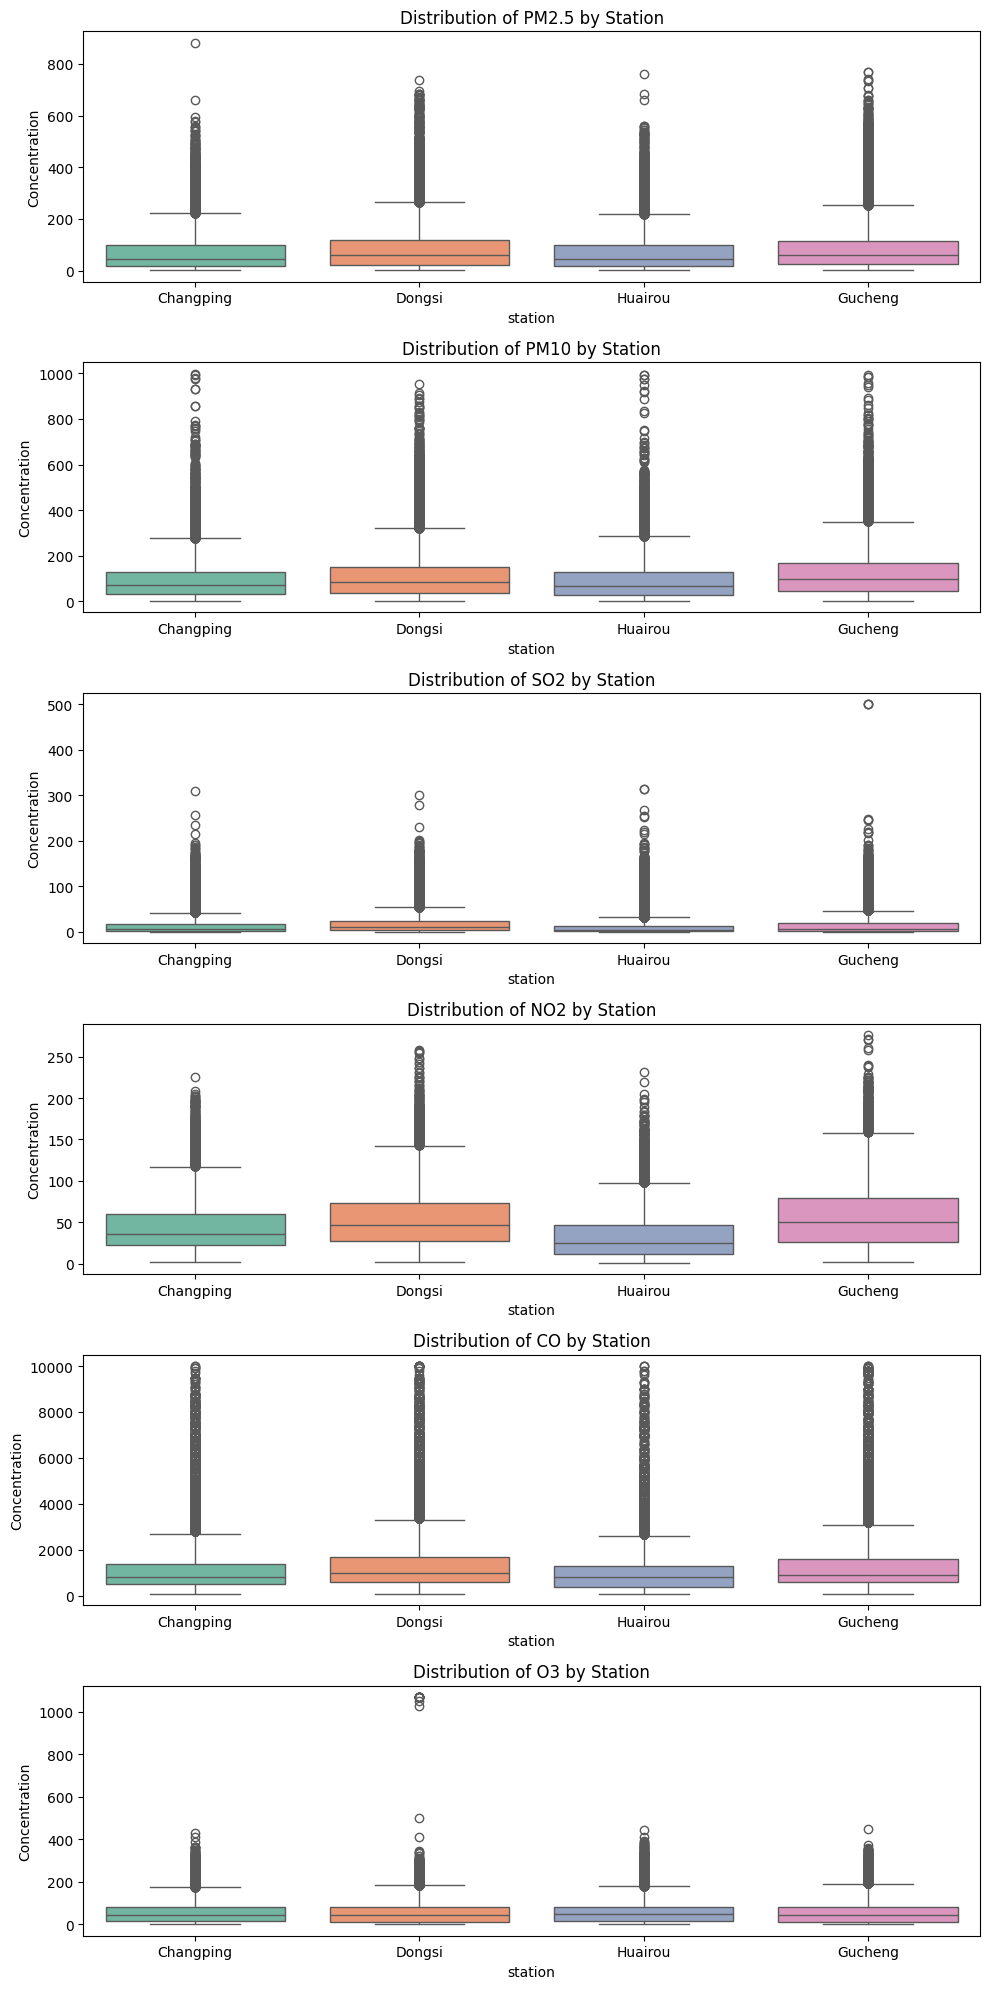

--- Outlier Detection Bounds (IQR Method) per Station ---


PM2.5   PM10   SO2       NO2      CO        O3
station                                                          
Changping Lower -105.000 -111.5 -22.0  -35.5373  -850.0  -80.9085
          Upper  223.000  276.5  42.0  117.8955  2750.0  176.5451
Dongsi    Lower -123.500 -131.5 -26.0  -42.0000 -1050.0  -91.5000
          Upper  264.500  320.5  54.0  142.0000  3350.0  184.5000
Gucheng   Lower -113.625 -138.0 -25.0  -53.5000  -900.0  -99.5000
          Upper  253.375  350.0  47.0  158.5000  3100.0  192.5000
Huairou   Lower -104.500 -126.5 -16.0  -39.0000  -950.0  -79.5000
          Upper  219.500  285.5  32.0   97.0000  2650.0  180.5000

In [24]:
# 1. Visualize distributions by station using boxplots
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 20))

for i, col in enumerate(pollutants):
    sns.boxplot(x='station', y=col, data=df, ax=axes[i], palette='Set2',hue='station',legend=False)
    axes[i].set_title(f'Distribution of {col} by Station')
    axes[i].set_ylabel('Concentration')

plt.tight_layout()
plt.show()

# 2. Compute IQR bounds per station for a quantitative summary
def get_iqr_bounds(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    return pd.Series({'Lower': Q1 - 1.5 * IQR, 'Upper': Q3 + 1.5 * IQR})

outlier_bounds = df.groupby('station')[pollutants].apply(lambda x: x.apply(get_iqr_bounds))
print("--- Outlier Detection Bounds (IQR Method) per Station ---")
display(outlier_bounds)

### **Inference from Station-wise Outlier Detection**

The station-wise box plots and IQR bounds show that all pollutant variables contain substantial upper-end outliers across the four stations. In every case, the distributions are **positively skewed**, with a large number of observations extending far above the upper whisker, which indicates that extreme pollution episodes are common in the dataset rather than isolated rare errors.

For **PM2.5** and **PM10**, all stations display many high-value outliers, but the urban stations, especially **Dongsi** and **Gucheng**, show wider spreads and higher upper bounds than the suburban stations. The IQR upper bounds for **PM2.5** are **264.5** in Dongsi and **253.4** in Gucheng, compared with **223.0** in Changping and **219.5** in Huairou. A similar pattern is observed for **PM10**, where **Gucheng (350.0)** and **Dongsi (320.5)** have higher upper bounds than **Huairou (285.5)** and **Changping (276.5)**. This suggests that urban stations experience stronger and more frequent extreme particulate pollution events.

For the gaseous pollutants, **NO2** and **CO** also show clear urban dominance in outlier behaviour. The upper IQR bound for **NO2** reaches **158.5** in Gucheng and **142.0** in Dongsi, whereas it is lower in Changping (**117.9**) and Huairou (**97.0**). For **CO**, the upper bounds are highest in **Dongsi (3350.0)** and **Gucheng (3100.0)**, compared with **2750.0** in Changping and **2650.0** in Huairou. These results imply that traffic and combustion-related emissions are more extreme and variable in the urban stations.

The **O3** box plot shows a slightly different pattern. While all stations contain many upper-end outliers, **Gucheng** has the highest IQR upper bound (**192.5**), followed by **Dongsi (184.5)**, **Huairou (180.5)**, and **Changping (176.5)**. However, Dongsi also shows exceptionally extreme O3 spikes above **1000**, which stand out far beyond the normal whisker range. This indicates that although overall O3 spread is fairly similar across stations, some urban episodes are unusually intense and may need special attention.

For **SO2**, outliers are again present at all stations, with **Dongsi** showing the highest upper bound (**54.0**) and **Gucheng** next (**47.0**), while Changping and Huairou remain lower. This reinforces the same station-wise pattern seen in the other pollutants, where urban locations tend to have both higher typical levels and more extreme pollution peaks.

Overall, the outlier analysis confirms that extreme pollutant values are a real and important characteristic of the dataset, especially in the urban stations. Since these high values may represent genuine severe pollution episodes rather than simple recording errors, they should not be removed blindly. A more suitable preprocessing approach would be to handle them **station-wise**, using methods such as capping or winsorization, while preserving the underlying spatial pollution differences across stations.